In [ ]:
# This notebook uses the test particle simulation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

times = np.load('results/times_halo.npy')
times_lmc = np.load('results/times_lmc.npy')
print(times)
pos_full = np.load('results/pos_full_plummer.npy') 
best_M = np.load('results/best_M.npy') 
best_a = np.load('results/best_a.npy') 

n_particles = pos_full.shape[1]
mass = np.full(n_particles, best_M / n_particles) 

i_now = np.argmin(np.abs(times - (-0.0)))
i_ini = np.argmin(np.abs(times - (-3.0)))

pos_raw = pos_full[:,:,i_now].T
pos_raw_ini = pos_full[:,:,i_ini].T

ro, vo = 8., 220.

[-3.   -2.85 -2.7  -2.55 -2.4  -2.25 -2.1  -1.95 -1.8  -1.65 -1.5  -1.35
 -1.2  -1.05 -0.9  -0.75 -0.6  -0.45 -0.3  -0.15  0.  ]


In [2]:
def density_center(P, m, fracs=(1.0, 0.7, 0.5, 0.35, 0.25, 0.18, 0.12)):
    """Shrinking-spheres density center.

    The halo has recoiled from the coordinate origin, and the mass-weighted COM is
    biased tens of kpc by the extended outer particles, so neither is a good SCF
    expansion center. Iteratively shrinking onto the densest region tracks the actual
    density peak, which is what the SCF basis must be centered on.
    """
    c = np.median(P, axis=0)
    for frac in fracs:
        r = np.linalg.norm(P - c, axis=1)
        sel = r < np.quantile(r, frac)
        c = np.average(P[sel], axis=0, weights=m[sel])
    return c


center = density_center(pos_raw, mass) 
center_ini = density_center(pos_raw_ini, mass) 
print('halo density center [kpc]:', np.round(center, 2))
print('mass-weighted COM   [kpc]:', np.round(np.average(pos_raw, axis=0, weights=mass), 2))

# Fit the SCF on particles recentered on the halo (NOT the coordinate origin).
pos = pos_raw - center
pos_ini = pos_raw_ini - center_ini
x, y, z = pos.T

halo density center [kpc]: [ 0.01  0.02 -0.02]
mass-weighted COM   [kpc]: [  76.51  -77.85 -230.43]


## SCF 

In [3]:
from galpy.potential import SCFPotential
import astropy.units as u

scf_halo = SCFPotential.from_nbody(pos_full*u.kpc, N=8, L=6, a=best_a*u.kpc, mass=mass*u.Msun, 
                                   tgrid=times*u.Gyr, ro=ro, vo=vo,symmetry=None)

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:1202: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))



/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:1164: RuntimeWarning: divide by zero encountered in divide
  K

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:1164: RuntimeWarning: invalid value encountered in divide
  K

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:868: RuntimeWarning: invalid value encountered in multiply
  radial[:, :, None] * (Acos * mcos + Asin * msin) * PP[None, :, :]



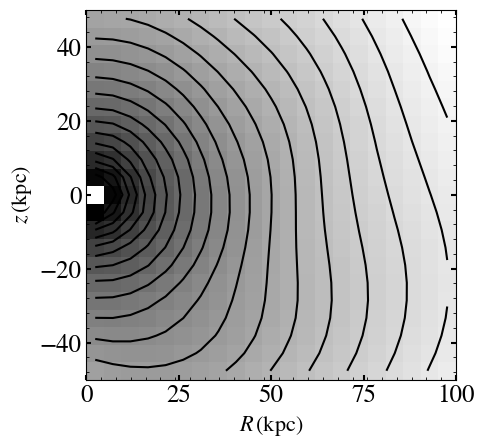

In [4]:
import astropy.units as u
scf_halo.plotDensity(rmax=100 * u.kpc, zmin = -50 * u.kpc, zmax=50 * u.kpc, aspect=1, phi=np.pi/2, log=True, t=-0.15*u.Gyr)

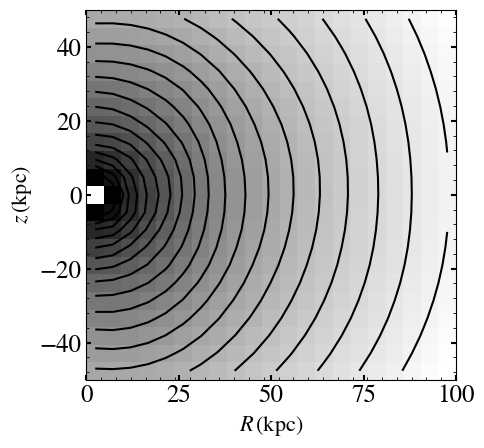

In [5]:
import astropy.units as u
scf_halo.plotDensity(rmax=100 * u.kpc, zmin = -50 * u.kpc, zmax=50 * u.kpc, aspect=1, phi=np.pi/2, log=True, t=-3*u.Gyr)

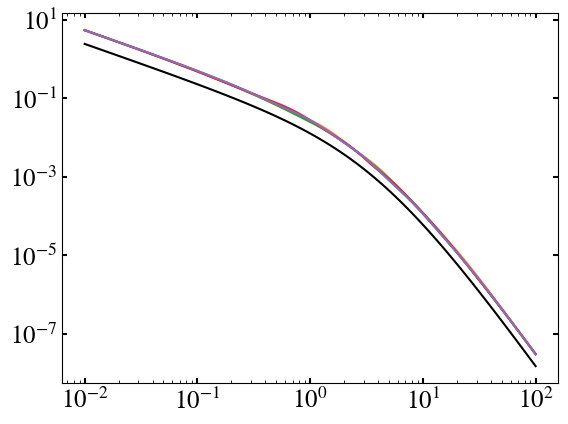

In [6]:
from galpy.potential import HernquistPotential
true_halo_ini = HernquistPotential(amp=best_M*u.Msun, a=best_a*u.kpc)
true_halo_ini.turn_physical_on()

scf_halo.turn_physical_on()
R_array = np.logspace(-2,2.,100)
phi_array = np.linspace(0, 2*np.pi, 5)
density_profile_base = np.array(true_halo_ini.dens(R_array,0.,t=-1.5*u.Gyr,phi=0))
plt.loglog(R_array,density_profile_base,color="k")
for phi in phi_array:
    density_profile = np.array(scf_halo.dens(R_array,0.,t=-1.5*u.Gyr,phi=phi))
    plt.loglog(R_array,density_profile)
plt.show()

## Gaussian Kernel

In [7]:
import numpy as np
from scipy.stats import gaussian_kde

In [8]:
mask = np.abs(pos[:,0]) < 20
yz = pos[mask,1:3]
kde = gaussian_kde(yz.T)

mask_ini = np.abs(pos_ini[:,0]) < 20
yz_ini = pos_ini[mask_ini,1:3]
kde_ini = gaussian_kde(yz_ini.T)

In [9]:
y = np.linspace(-200, 200, 50)
z = np.linspace(-200, 200, 50)
Y, Z = np.meshgrid(y, z)

points = np.vstack([Y.ravel(), Z.ravel()])
Sigma = kde(points).reshape(Y.shape)
Sigma_ini = kde_ini(points).reshape(Y.shape)

Text(0, 0.5, 'z')

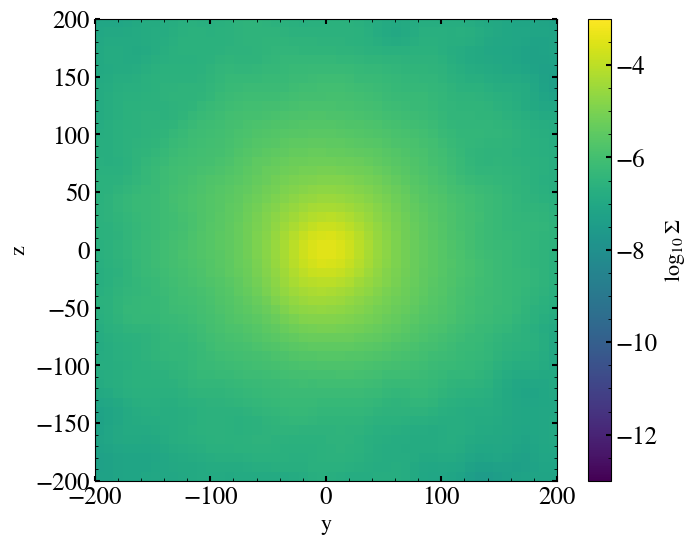

In [10]:
plt.figure(figsize=(8, 6))

plt.imshow(
    np.log10(Sigma),
    origin='lower',
    extent=[y.min(), y.max(), z.min(), z.max()],
    aspect='equal',
    vmin=-13,
    vmax=-3
)

plt.colorbar(label=r'$\log_{10}\Sigma$')
plt.xlabel('y')
plt.ylabel('z')

Text(0, 0.5, 'z')

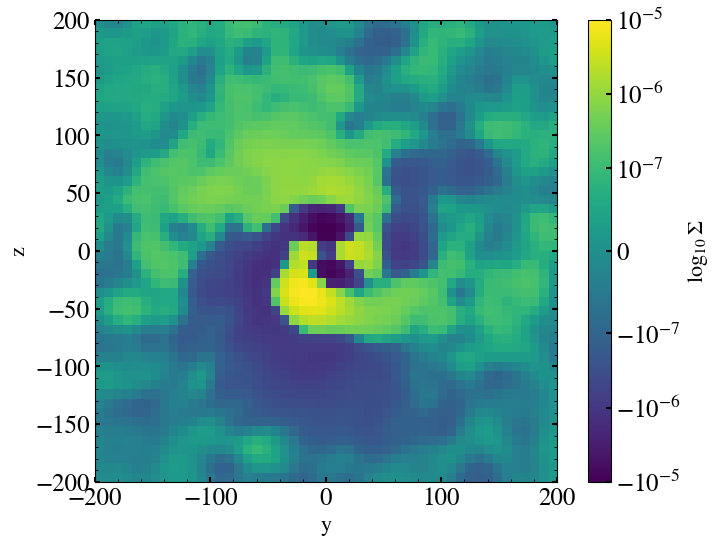

In [11]:
from matplotlib.colors import SymLogNorm
plt.figure(figsize=(8, 6))
plt.imshow(
    Sigma - Sigma_ini,
    origin='lower',
    extent=[y.min(), y.max(), z.min(), z.max()],
    aspect='equal',
    norm=SymLogNorm(linthresh=1e-7, linscale=1.0, vmin=-1e-5, vmax=1e-5)
)

plt.colorbar(label=r'$\log_{10}\Sigma$')
plt.xlabel('y')
plt.ylabel('z')

## SCF density vs. particle histogram

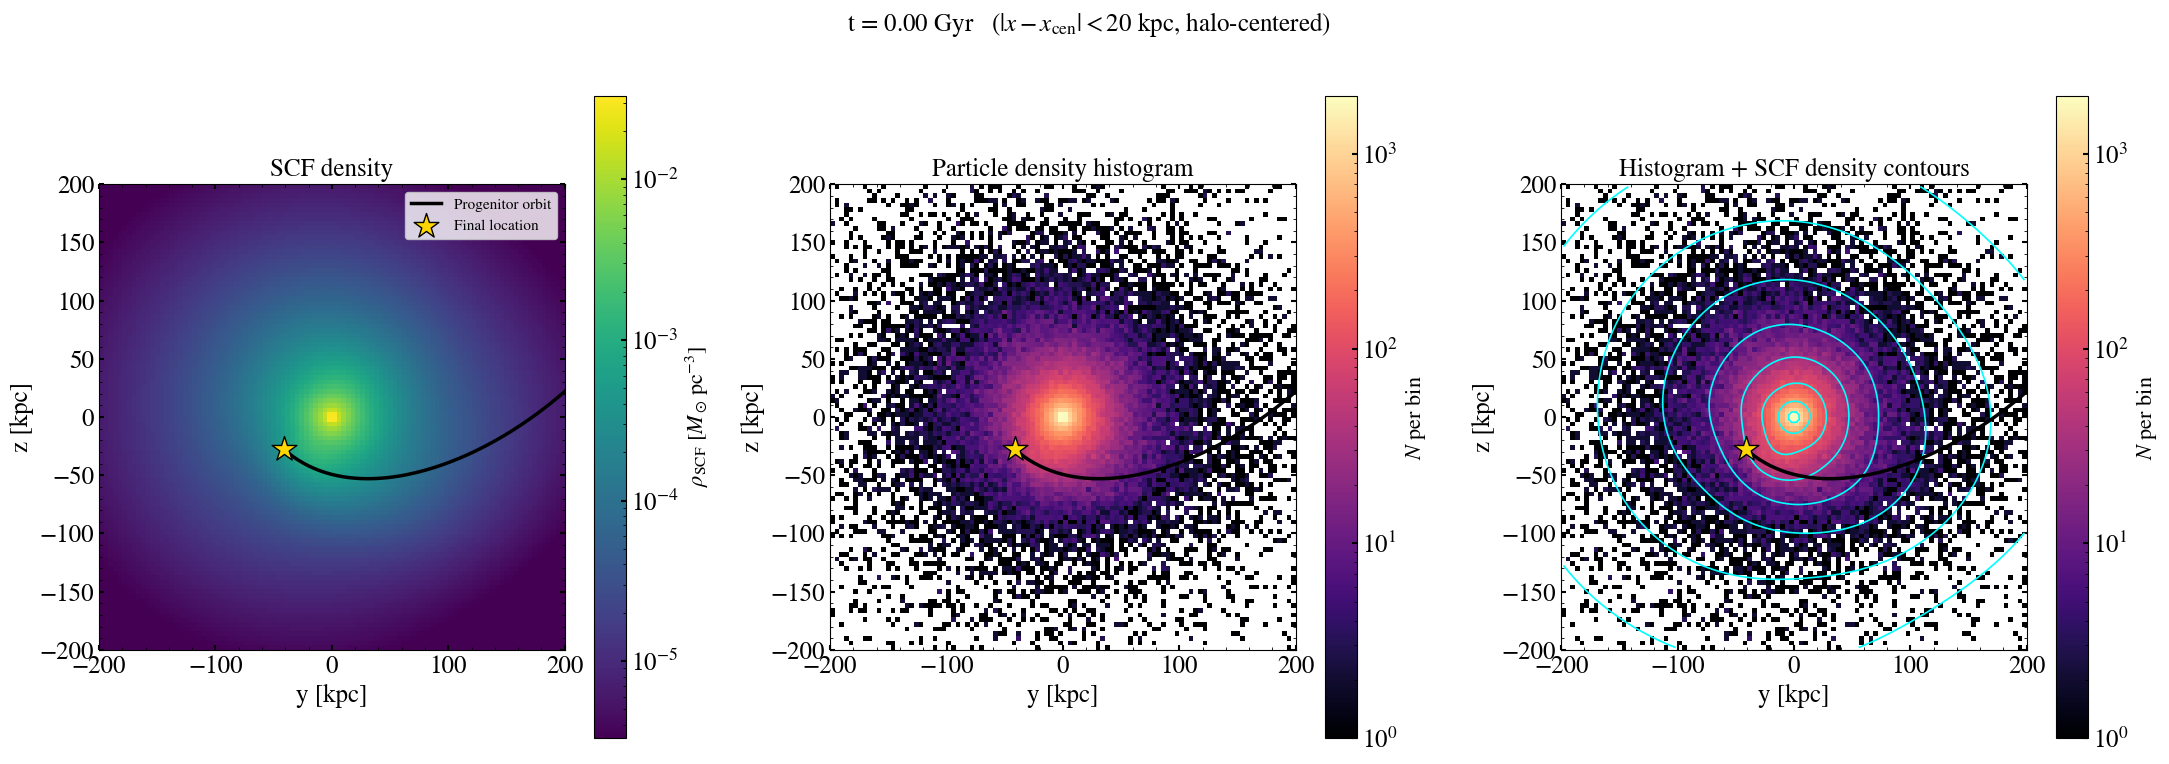

In [12]:
from matplotlib.colors import LogNorm
import astropy.units as u

o_lmc_x = np.load('results/o_lmc_x_plummer.npy')
o_lmc_y = np.load('results/o_lmc_y_plummer.npy')
o_lmc_z = np.load('results/o_lmc_z_plummer.npy')

# ----- slice / grid settings (mirror the original delta-N plot) -----
t_final = 0.0              # snapshot the SCF (`pot`) and `center` were built from
slice_halfwidth = 20.0       # kpc; |x_centered| < slice_halfwidth
bins = 100
extent = (-200, 200, -200, 200)
yedges = np.linspace(extent[0], extent[1], bins + 1)
zedges = np.linspace(extent[2], extent[3], bins + 1)
yc = 0.5 * (yedges[:-1] + yedges[1:])
zc = 0.5 * (zedges[:-1] + zedges[1:])

# Work in the recentered frame (`center` from the cell above) so the SCF density
# and the particle histogram share the same origin = halo density center.
sl = np.abs(pos[:,0]) < slice_halfwidth        # x-slab around the halo center
H, _, _ = np.histogram2d(pos[sl,1], pos[sl,2], bins=[yedges, zedges])

# SCF density (Msun/pc^3) averaged through the same x-slab
Y, Z = np.meshgrid(yc, zc)                       # shape (z, y)
xplanes = np.linspace(-slice_halfwidth, slice_halfwidth, 5)
dens = np.zeros_like(Y)
for xv in xplanes:
    R = np.sqrt(xv**2 + Y**2)
    phi = np.arctan2(Y, np.full_like(Y, xv))
    dens += np.array(scf_halo.dens(R.ravel() * u.kpc, Z.ravel() * u.kpc,
                              phi.ravel())).reshape(Y.shape)
dens /= len(xplanes)

dmax = np.nanmax(dens)
dens_pos = np.where(dens > 0, dens, np.nan)       # mask negative ringing (rho < 0)
# log-spaced levels over ~4 decades so contours reach the outskirts, not just the core.
# (They still stop where the SCF rings negative -- there is no positive rho to trace.)
levels = dmax * np.logspace(-4, -0.2, 8)

# progenitor (satellite) orbit up to t_final, in the same recentered frame
i_final =np.argmin(np.abs(times_lmc - t_final))
sy = o_lmc_y[:i_final+1] - center[1]
sz = o_lmc_z[:i_final+1] - center[2]

def _overlay(ax):
    ax.plot(sy, sz, c='k', lw=2.5, label='Progenitor orbit')
    ax.scatter(sy[-1], sz[-1], s=350, marker='*', color='gold',
               edgecolor='k', zorder=5, label='Final location')
    ax.set_xlim(extent[:2]); ax.set_ylim(extent[2:])
    ax.set_xlabel('y [kpc]', fontsize=18); ax.set_ylabel('z [kpc]', fontsize=18)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

# Panel 1: SCF density
im0 = axes[0].imshow(dens_pos, origin='lower', extent=extent,
                     norm=LogNorm(vmin=dmax * 1e-4, vmax=dmax), cmap='viridis')
axes[0].set_title('SCF density', fontsize=18)
fig.colorbar(im0, ax=axes[0], label=r'$\rho_{\rm SCF}$ [$M_\odot\,{\rm pc}^{-3}$]')
_overlay(axes[0]); axes[0].legend(loc='upper right', fontsize=11)

# Panel 2: particle density histogram
im1 = axes[1].imshow(H.T, origin='lower', extent=extent,
                     norm=LogNorm(vmin=1, vmax=H.max()), cmap='magma')
axes[1].set_title('Particle density histogram', fontsize=18)
fig.colorbar(im1, ax=axes[1], label=r'$N$ per bin')
_overlay(axes[1])

# Panel 3: histogram + SCF density contours
im2 = axes[2].imshow(H.T, origin='lower', extent=extent,
                     norm=LogNorm(vmin=1, vmax=H.max()), cmap='magma')
axes[2].contour(yc, zc, dens_pos, levels=levels, colors='cyan', linewidths=1.2)
axes[2].set_title('Histogram + SCF density contours', fontsize=18)
fig.colorbar(im2, ax=axes[2], label=r'$N$ per bin')
_overlay(axes[2])

fig.suptitle(f't = {t_final:.2f} Gyr   '
             rf'($|x - x_{{\rm cen}}| < {slice_halfwidth:.0f}$ kpc, halo-centered)',
             fontsize=18, y=1.02)
plt.tight_layout()
#plt.savefig('02c_scf_density_yz_slice.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
print(o_lmc_x)

[ -8.98034887  -9.11447177  -9.24831072  -9.38186036  -9.51511531
  -9.6480701   -9.78071922  -9.91305711 -10.04507814 -10.1767766
 -10.30814676 -10.43918277 -10.56987876 -10.70022877 -10.83022677
 -10.95986666 -11.08914229 -11.21804739 -11.34657565 -11.47472067
 -11.60247598 -11.729835   -11.85679109 -11.98333753 -12.10946748
 -12.23517406 -12.36045024 -12.48528893 -12.60968295 -12.733625
 -12.85710768 -12.9801235  -13.10266486 -13.22472403 -13.3462932
 -13.46736442 -13.58792965 -13.70798069 -13.82750925 -13.9465069
 -14.06496508 -14.18287511 -14.30022815 -14.41701525 -14.53322728
 -14.64885499 -14.76388897 -14.87831966 -14.99213733 -15.1053321
 -15.21789392 -15.32981255 -15.44107759 -15.55167847 -15.6616044
 -15.77084443 -15.87938739 -15.98722192 -16.09433646 -16.20071921
 -16.30635818 -16.41124113 -16.5153556  -16.61868889 -16.72122804
 -16.82295987 -16.92387091 -17.02394742 -17.12317539 -17.22154055
 -17.31902829 -17.41562374 -17.51131169 -17.60607663 -17.6999027
 -17.79277371 -17.

## Density perturbation

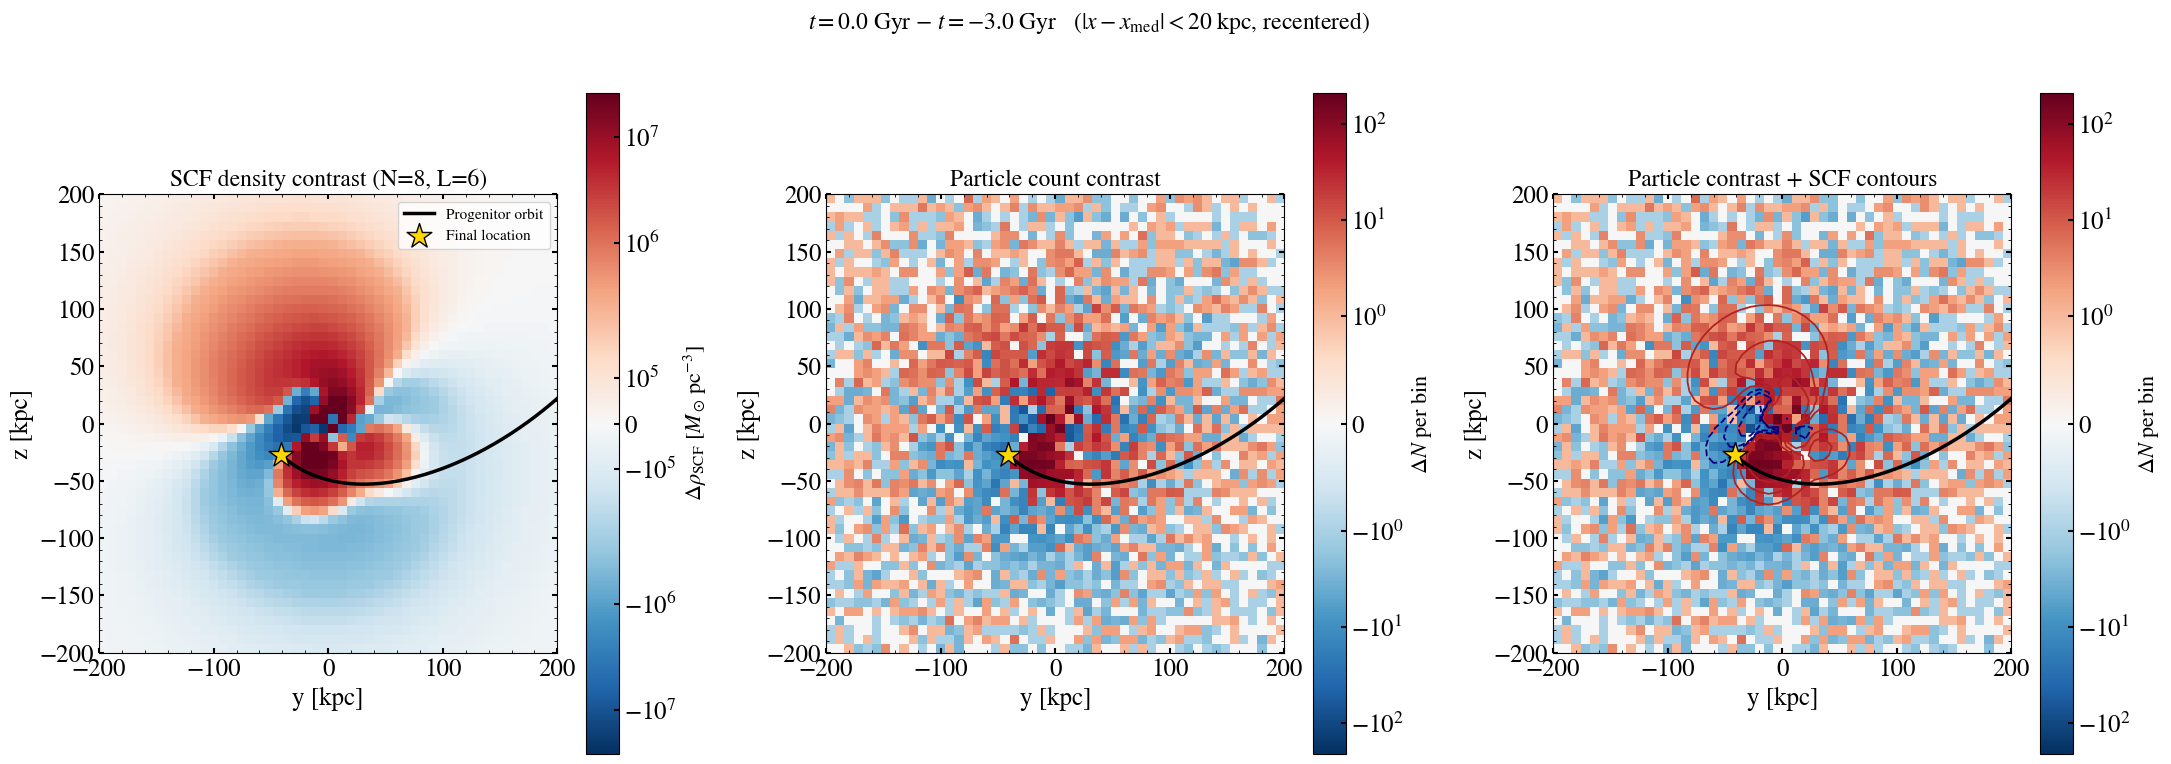

In [14]:
from matplotlib.colors import SymLogNorm
from galpy.potential import scf_compute_coeffs_nbody
import astropy.units as u

ro = 8.

# ---- SCF settings (see note above): low-L is fast and captures the wake ----
N_scf, L_scf = 8, 6
t_init, t_final = -3.0, 0.0
slice_halfwidth = 20.0
bins = 50
extent = (-200, 200, -200, 200)
yedges = np.linspace(extent[0], extent[1], bins + 1)
zedges = np.linspace(extent[2], extent[3], bins + 1)
yc = 0.5 * (yedges[:-1] + yedges[1:]); zc = 0.5 * (zedges[:-1] + zedges[1:])

def recentered(t):
    """Particles at time t, recentered to their median (removes bulk reflex shift)."""
    i = np.argmin(np.abs(times - t))
    p = pos_full[:,:,i].T
    c = density_center(p,mass)
    return p - c

def scf_pot(p):
    Ac, As = scf_compute_coeffs_nbody((p / ro).T, N=N_scf, L=L_scf, mass=mass)
    pot = SCFPotential(Acos=Ac, Asin=As)
    pot.turn_physical_on(ro=ro)
    return pot

def slab_density(pot):
    """SCF density [Msun/pc^3] averaged through the |x| < slice_halfwidth slab."""
    Y, Z = np.meshgrid(yc, zc)
    acc = np.zeros_like(Y)
    xplanes = np.linspace(-slice_halfwidth, slice_halfwidth, 3)
    for xv in xplanes:
        R = np.sqrt(xv**2 + Y**2); phi = np.arctan2(Y, np.full_like(Y, xv))
        acc += np.array(pot.dens(R.ravel() * u.kpc, Z.ravel() * u.kpc,
                                 phi.ravel())).reshape(Y.shape)
    return acc / len(xplanes)

def hist_slab(p):
    sl = np.abs(p[:, 0]) < slice_halfwidth
    H, _, _ = np.histogram2d(p[sl, 1], p[sl, 2], bins=[yedges, zedges])
    return H

p0, pN = recentered(t_init), recentered(t_final)
dRho = slab_density(scf_pot(pN)) - slab_density(scf_pot(p0))   # SCF contrast
dH = hist_slab(pN) - hist_slab(p0)                             # particle contrast

# diverging norms (match the original SymLogNorm ΔN style)
hr_d = np.nanpercentile(np.abs(dRho), 99.5)
norm_d = SymLogNorm(linthresh=hr_d * 1e-2, vmin=-hr_d, vmax=hr_d, base=10)
hr_h = max(np.abs(dH).max(), 1.0)
norm_h = SymLogNorm(linthresh=1, vmin=-hr_h, vmax=hr_h, base=10)
cmap = plt.get_cmap('RdBu_r'); cmap.set_bad('k')

pos_lv = hr_d * np.array([0.05, 0.15, 0.4])
neg_lv = -pos_lv[::-1]

# progenitor orbit, recentered to the final-snapshot halo median
med_f = density_center(pos_full[:,:,np.argmin(np.abs(times - t_final))].T, mass)
i_f = np.argmin(np.abs(times_lmc - t_final))
sy = o_lmc_y[:i_f + 1] - med_f[1]
sz = o_lmc_z[:i_f + 1] - med_f[2]

def _overlay(ax):
    ax.plot(sy, sz, c='k', lw=2.5, label='Progenitor orbit')
    ax.scatter(sy[-1], sz[-1], s=350, marker='*', color='gold',
               edgecolor='k', zorder=5, label='Final location')
    ax.set_xlim(extent[:2]); ax.set_ylim(extent[2:])
    ax.set_xlabel('y [kpc]', fontsize=18); ax.set_ylabel('z [kpc]', fontsize=18)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

im0 = axes[0].imshow(dRho, origin='lower', extent=extent, norm=norm_d, cmap=cmap)
axes[0].set_title(f'SCF density contrast (N={N_scf}, L={L_scf})', fontsize=17)
fig.colorbar(im0, ax=axes[0], label=r'$\Delta\rho_{\rm SCF}$ [$M_\odot\,{\rm pc}^{-3}$]')
_overlay(axes[0]); axes[0].legend(loc='upper right', fontsize=11)

im1 = axes[1].imshow(dH.T, origin='lower', extent=extent, norm=norm_h, cmap=cmap)
axes[1].set_title('Particle count contrast', fontsize=17)
fig.colorbar(im1, ax=axes[1], label=r'$\Delta N$ per bin')
_overlay(axes[1])

im2 = axes[2].imshow(dH.T, origin='lower', extent=extent, norm=norm_h, cmap=cmap)
axes[2].contour(yc, zc, dRho, levels=pos_lv, colors='firebrick', linewidths=1.3)
axes[2].contour(yc, zc, dRho, levels=neg_lv, colors='navy', linewidths=1.3,
                linestyles='--')
axes[2].set_title('Particle contrast + SCF contours', fontsize=17)
fig.colorbar(im2, ax=axes[2], label=r'$\Delta N$ per bin')
_overlay(axes[2])

fig.suptitle(rf'$t={t_final:.1f}$ Gyr $-$ $t={t_init:.1f}$ Gyr   '
             rf'($|x-x_{{\rm med}}|<{slice_halfwidth:.0f}$ kpc, recentered)',
             fontsize=17, y=1.02)
plt.tight_layout()
#plt.savefig('02d_scf_density_contrast.png', dpi=200, bbox_inches='tight')
plt.show()


## Multipole expansion from SCF

##

In [15]:
from galpy.potential import MultipoleExpansionPotential

rgrid = np.geomspace(1e-3, 200.0, 601)
mep_halo = MultipoleExpansionPotential.from_scf(scf_halo, rgrid=rgrid, ro=ro, vo=vo)

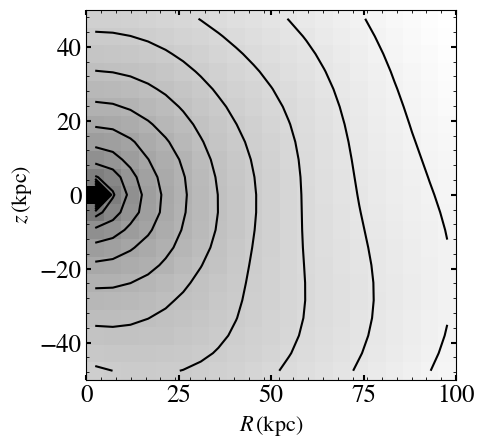

In [16]:
mep_halo.plotDensity(rmax=100 * u.kpc, zmin = -50 * u.kpc, zmax=50 * u.kpc, aspect=1, phi=np.pi/2, log=True, t=-0.15*u.Gyr)

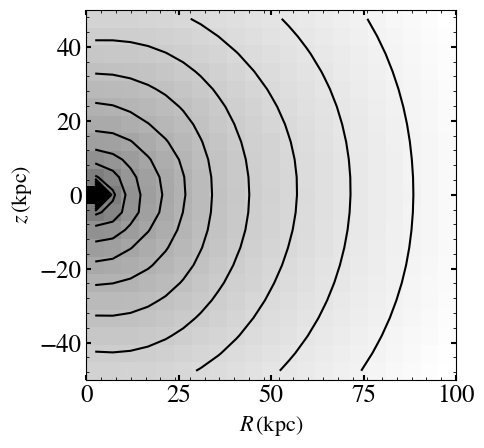

In [17]:
mep_halo.plotDensity(rmax=100 * u.kpc, zmin = -50 * u.kpc, zmax=50 * u.kpc, aspect=1, phi=np.pi/2, log=True, t=-3*u.Gyr)

In [18]:
from galpy.potential import PlummerPotential, MovingObjectPotential
from galpy.orbit import Orbit

lmc = PlummerPotential(amp=1.5e11*u.Msun,b=10*u.kpc)
o_lmc = Orbit.from_name("LMC")

In [19]:
from galpy.potential import ChandrasekharDynamicalFrictionForce
from galpy.df import isotropicHernquistdf

halo_potential = HernquistPotential(amp=best_M * u.Msun, a=best_a * u.kpc)
hq_df = isotropicHernquistdf(pot=halo_potential)

lmc.turn_physical_on(ro=ro,vo=vo)

friction = ChandrasekharDynamicalFrictionForce(GMs=1.5e11* u.Msun,sigmar=lambda r: hq_df.sigmar(r,use_physical=False))
ts_bckwd = np.linspace(0,-3,2001)*u.Gyr
o_lmc.integrate(ts_bckwd,[halo_potential,friction,lmc],method="dop853_c")

lmc_moving = MovingObjectPotential(o_lmc,pot=lmc)

In [20]:
from galpy.potential import evaluateRforces, evaluatephitorques, evaluatezforces
from galpy.util import conversion
from galpy.potential import NonInertialFrameForce

loc_origin = 1e-4

ro, vo = 8.0 * u.kpc, 220.0 * u.km / u.s
    
ts_fwd = np.linspace(-3., 0., 200) * u.Gyr
t_galpy = o_lmc.time(use_physical=False)[::-1]

ax = np.array([evaluateRforces(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy])
ay = np.array([evaluatephitorques(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy]) / loc_origin
az = np.array([evaluatezforces(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy])
    
time_unit = conversion.time_in_Gyr(vo=vo.value, ro=ro.value)
ts_fwd_galpy = ts_fwd.value / time_unit  # convert Gyr -> galpy units

ax_int = lambda t: np.interp(t,t_galpy,ax)
ay_int = lambda t: np.interp(t,t_galpy,ay)
az_int = lambda t: np.interp(t,t_galpy,az)
    
nif = NonInertialFrameForce(a0=[ax_int,ay_int,az_int])

In [21]:
ts = np.linspace(-3.0,0,100)

test_galaxy_base = Orbit.from_name("Fornax")
base_potential = HernquistPotential(amp=best_M * u.Msun, a=best_a * u.kpc)
test_galaxy_base.integrate(ts*u.Gyr,base_potential)

test_galaxy_scf = Orbit.from_name("Fornax")
test_galaxy_scf.integrate(ts*u.Gyr,[scf_halo])

test_galaxy_full = Orbit.from_name("Fornax")
test_galaxy_full.integrate(ts*u.Gyr,[scf_halo,lmc_moving,nif])

test_galaxy_lmc_nif = Orbit.from_name("Fornax")
test_galaxy_lmc_nif.integrate(ts*u.Gyr,[base_potential,lmc_moving,nif])

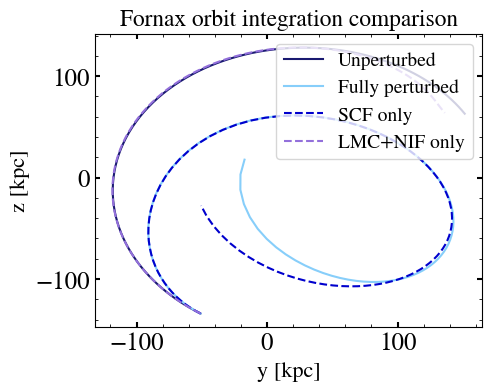

In [22]:
plt.figure(figsize=(5,3.8))
plt.plot(test_galaxy_base.y(ts*u.Gyr),test_galaxy_base.z(ts*u.Gyr),label="Unperturbed",color="midnightblue")
plt.plot(test_galaxy_full.y(ts*u.Gyr),test_galaxy_full.z(ts*u.Gyr),label="Fully perturbed",color="lightskyblue")
plt.plot(test_galaxy_scf.y(ts*u.Gyr),test_galaxy_scf.z(ts*u.Gyr),label="SCF only",color="mediumblue",ls="--")
plt.plot(test_galaxy_lmc_nif.y(ts*u.Gyr),test_galaxy_lmc_nif.z(ts*u.Gyr),label="LMC+NIF only",color="mediumpurple",ls="--")
plt.xlabel("y [kpc]")
plt.ylabel("z [kpc]")
plt.title("Fornax orbit integration comparison")
plt.legend(loc="upper right")

In [23]:
from galpy.potential import scf_compute_coeffs_nbody
from galpy.util import conversion

pos_scf_internal = pos_full[:,:,-1] / ro   # (n_particles, 3) -> (3, n_particles)
mass_to_internal = conversion.mass_in_msol(vo,ro)
mass_internal = mass / mass_to_internal
best_a_internal = best_a / ro

Acos, Asin = scf_compute_coeffs_nbody(pos_scf_internal, N=8, L=6, mass=mass_internal, a=best_a_internal)

np.set_printoptions(precision=6,suppress=True)

print(pos_full.shape)

print(Acos)
print(Asin)


/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/astropy/units/quantity.py:648: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)

(3, 250000, 21)
[[[58.860239  0.        0.        0.        0.        0.      ]
  [ 0.632024 -0.041297  0.        0.        0.        0.      ]
  [ 3.929539 -0.77552  -0.619656  0.        0.        0.      ]
  [-4.327651  1.970136  2.143873 -1.20588   0.        0.      ]
  [ 3.551667 -2.69366  -4.239497  0.160447  2.014243  0.      ]
  [ 0.326177  3.396995  8.1879   -3.904852 -0.481021 -1.488618]]

 [[-0.255816  0.        0.        0.        0.        0.      ]
  [ 0.454529 -0.040754  0.        0.        0.        0.      ]
  [ 0.478789 -0.180342 -0.156471  0.        0.        0.      ]
  [-0.256645  0.204317  0.358174 -0.090005  0.        0.      ]
  [ 0.320777 -0.21984  -0.443615  0.06734 

In [24]:
C_nl = np.sum(Acos**2 + Asin**2,axis=2) # sums over m since axis 0 is n, 1 is l, 2 is m

print(C_nl)
C_00 = C_nl[0,0]

C_nl_norm = C_nl/C_00

print(C_nl_norm)

[[3464.527751    0.402868   17.087956   30.991113  100.357907  234.229505]
 [   0.065442    0.212651    0.338646    0.297796    0.607294    9.104239]
 [   0.009272    0.033811    0.042637    0.01487     0.037668    0.204869]
 [   0.000024    0.001209    0.003791    0.002065    0.007611    0.022319]
 [   0.000678    0.000397    0.000144    0.00045     0.000501    0.003153]
 [   0.000057    0.000073    0.000048    0.000115    0.000219    0.000264]
 [   0.000012    0.000002    0.000007    0.000004    0.00001     0.000033]
 [   0.000032    0.000002    0.000004    0.000002    0.000006    0.000005]]
[[1.       0.000116 0.004932 0.008945 0.028967 0.067608]
 [0.000019 0.000061 0.000098 0.000086 0.000175 0.002628]
 [0.000003 0.00001  0.000012 0.000004 0.000011 0.000059]
 [0.       0.       0.000001 0.000001 0.000002 0.000006]
 [0.       0.       0.       0.       0.       0.000001]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]


<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

/tmp/ipykernel_2096601/3752107891.py:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.set_title("$C_{nl} = \sum_{m}$ $|A_{nlm}|^2 + |B_{nlm}|^2$")



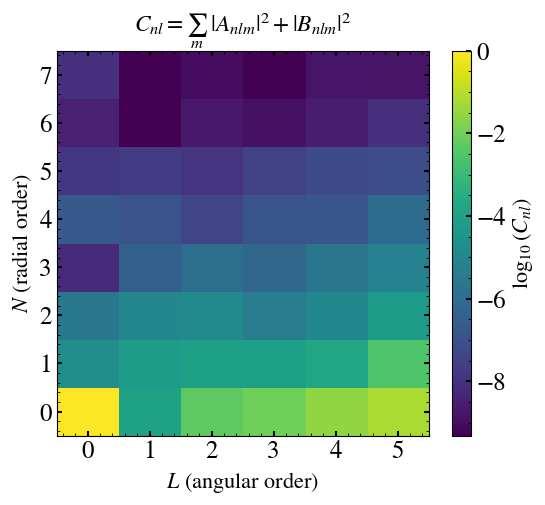

In [25]:
fig, ax = plt.subplots(figsize=(6,5))

data = np.log10(C_nl_norm)

im = ax.imshow(data, origin="lower", aspect="auto", cmap="viridis")
ax.set_xlabel("$L$ (angular order)")
ax.set_ylabel("$N$ (radial order)")
ax.set_title("$C_{nl} = \sum_{m}$ $|A_{nlm}|^2 + |B_{nlm}|^2$")
ax.set_xticks(range(C_nl.shape[1]))
ax.set_yticks(range(C_nl.shape[0]))

cbar = plt.colorbar(im,ax=None) 
cbar.set_label(r"$\log_{10}(C_{nl})$")

plt.tight_layout
plt.show()

In [26]:
gd1 = Orbit.from_name("GD-1")
from galpy.df import chen24spraydf
spdf = chen24spraydf(progenitor_mass=2*10**4.0 * u.Msun,
                          progenitor=gd1,
                          pot=scf_halo,
                          tdisrupt = 4.5*u.Gyr,
                          tail="both")

both_stream = spdf.sample(n=1000)

spdf_base = chen24spraydf(progenitor_mass=2*10**4.0 * u.Msun,
                          progenitor=gd1,
                          pot=base_potential,
                          tdisrupt = 4.5*u.Gyr,
                          tail="both")

both_stream_base = spdf_base.sample(n=1000)

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/Potential.py:4267: RuntimeWarning: invalid value encountered in power
  return (M / (omegac2 - d2phidr2)) ** (1.0 / 3.0)



(-12.5, 12.5)

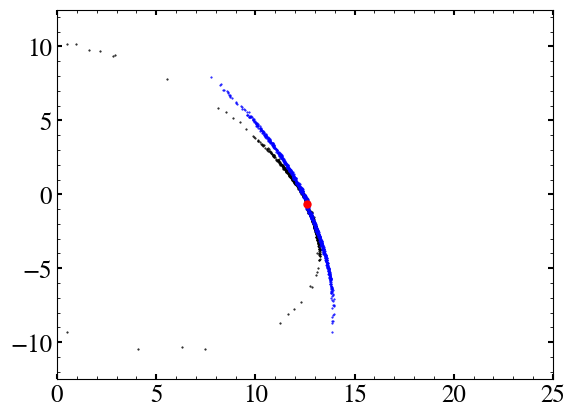

In [27]:

plt.plot(both_stream.x(),both_stream.y(), "k.", ms=1)
plt.plot(both_stream_base.x(),both_stream_base.y(), "b.", ms=1)
plt.plot(gd1.x(),gd1.y(),"ro",ms=5)
plt.xlim(0,25)
plt.ylim(-12.5,12.5)

(-12.5, 12.5)

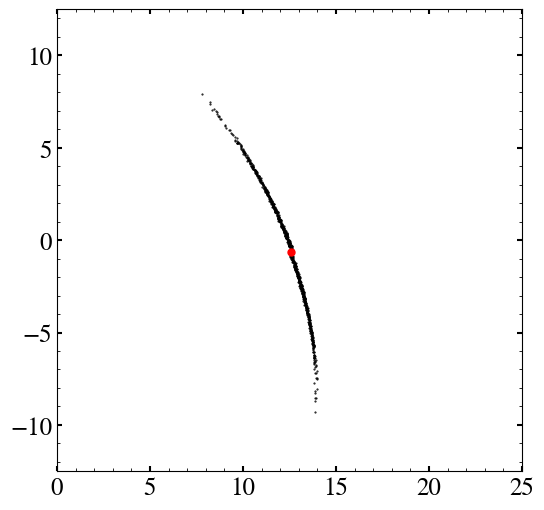

In [28]:
plt.figure(figsize=(6,6))
plt.plot(both_stream_base.x(),both_stream_base.y(), "k.", ms=1)
plt.plot(gd1.x(),gd1.y(),"ro",ms=5)
plt.xlim(0,25)
plt.ylim(-12.5,12.5)